The old script uses a calibration based on PROMICE and GEM AWS data. Adjust to SATLST and use coefficients from the coef script. Two ways: Either calibrate and save as GEOTIFF or calibrate on the fly when gapfilling?? 

In [ ]:
import numpy as np
import rasterio as rio
from rasterio.plot import show
import pandas as pd
from pathlib import Path

# Mute later:
# import matplotlib.pyplot as plt
# from matplotlib.colors import LinearSegmentedColormap

In [ ]:
icemask = rio.open('/home/jovyan/work/AVOCA/GEM/Development/Data/Masks/Icemask.tif')
landmask = rio.open('/home/jovyan/work/AVOCA/GEM/Development/Data/Masks/Landmask.tif')

# ADD NEW COEFFICIENTS, UPLOAD TO ASSETS AND UIPDATE THE TABLE IMPORT
# coef_era5 = pd.read_csv('coefficients_lookup_era5.csv')
# coef_land = coef_era5[coef_era5['area']=='land']
# coef_ice = coef_era5[coef_era5['area']=='ice']
# print(coef_era5)

In [2]:
# ERA5 Data: 
imfolder = "C:/Users/simon/OneDrive - University of Copenhagen/Documents/Arbeitsmappe/GEMLST/GEMLST/GEMLST_MODIS/Data/Test_Gapfilling/GL1000m_reproj" # "./GL1000m_reproj/"
imfiles = sorted(Path(imfolder).glob("*.tif"))

# # CORRUPTED FILES TO EXCLUDE
# #	t2m_elvcorr_2001_d201 until t2m_elvcorr_2001_d210
# #	t2m_elvcorr_2001_d339 until t2m_elvcorr_2001_d349
# #	t2m_elvcorr_2019_d160

# # markers (adjust if you need case-insensitive match or different substrings)
# start_marker = "t2m_1000m_2000_d001.tif" # OBS D11
# end_marker = "t2m_1000m_2000_d005.tif"   # OBS LEAP YEARS

# # find first index containing the start marker and last index containing the end marker
# start_idx = next((i for i, p in enumerate(imfiles) if start_marker in p.name), None)
# end_idx = next((i for i, p in enumerate(imfiles) if end_marker in p.name), None)

# if start_idx is None:
#     raise FileNotFoundError(f"No file containing '{start_marker}' found under {imfolder}")
# if end_idx is None:
#     raise FileNotFoundError(f"No file containing '{end_marker}' found under {imfolder}")
# if end_idx < start_idx:
#     raise ValueError(f"End file '{end_marker}' appears before start file '{start_marker}' in sorted file order")

# # slice inclusive range
# imfiles = imfiles[start_idx:end_idx + 1]

# imfiles = 

In [3]:
print(imfiles)

[WindowsPath('C:/Users/simon/OneDrive - University of Copenhagen/Documents/Arbeitsmappe/GEMLST/GEMLST/GEMLST_MODIS/Data/Test_Gapfilling/GL1000m_reproj/t2m_1000m_2000_d001.tif'), WindowsPath('C:/Users/simon/OneDrive - University of Copenhagen/Documents/Arbeitsmappe/GEMLST/GEMLST/GEMLST_MODIS/Data/Test_Gapfilling/GL1000m_reproj/t2m_1000m_2000_d002.tif'), WindowsPath('C:/Users/simon/OneDrive - University of Copenhagen/Documents/Arbeitsmappe/GEMLST/GEMLST/GEMLST_MODIS/Data/Test_Gapfilling/GL1000m_reproj/t2m_1000m_2000_d003.tif')]


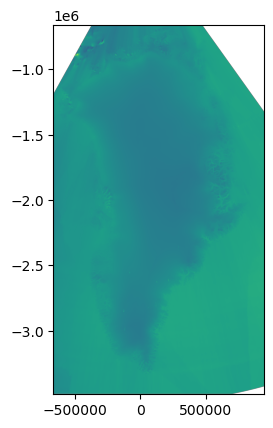

File C:\Users\simon\OneDrive - University of Copenhagen\Documents\Arbeitsmappe\GEMLST\GEMLST\GEMLST_MODIS\Data\Test_Gapfilling\GL1000m_reproj\t2m_1000m_2000_d001.tif reprojected and calibrated


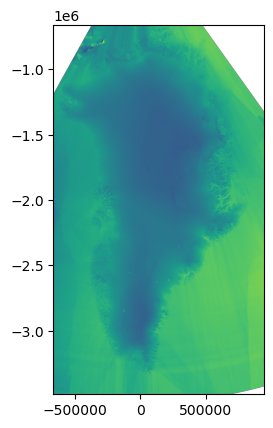

File C:\Users\simon\OneDrive - University of Copenhagen\Documents\Arbeitsmappe\GEMLST\GEMLST\GEMLST_MODIS\Data\Test_Gapfilling\GL1000m_reproj\t2m_1000m_2000_d002.tif reprojected and calibrated


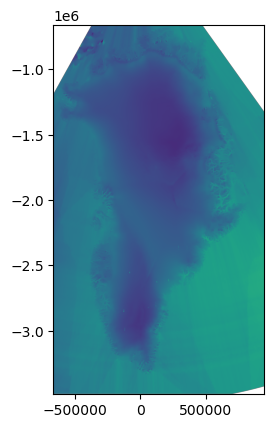

File C:\Users\simon\OneDrive - University of Copenhagen\Documents\Arbeitsmappe\GEMLST\GEMLST\GEMLST_MODIS\Data\Test_Gapfilling\GL1000m_reproj\t2m_1000m_2000_d003.tif reprojected and calibrated
ALL FILES DONE


In [ ]:
for imfile in imfiles:
    with rio.open(imfile) as img:
        
### CALIBRATION ###

    era5_land = img * coef_land['coef_before'].values[0] + coef_land['intercept_before'].values[0]
    era5_ice = img * coef_ice['coef_before'].values[0] + coef_ice['intercept_before'].values[0]
    
    era5_calibrated = np.where(landmask.read(1) == 1, era5_land, np.where(icemask.read(1) == 1, era5_ice, np.nan))
    
    # show(era5_calibrated)


### SAVE FILE ### 
    output_file = './GL1000m_reproj_cal/t2m_1000m_cal_FILENAME.tif'
    output_file = output_file.replace("FILENAME", imfile.stem.split('_',2)[2])
    # with rio.open(output_file, 'w', driver='GTiff', height=lst_height, width=lst_width, count=1, dtype=np.float32, crs=lst_crs, transform=lst_transform) as dst:
    #     dst.write(era5_calibrated, 1) ### Check if necessary here. Data already in correct format. Easier / faster way to save? 

### PRINTS###
    # Every round
    print(f'File {imfile} calibrated')

# Confirm loop completion
print('ALL FILES DONE')    

In [ ]:
pfad = '/home/jovyan/work/AVOCA/GEM/Development/Data/ERA5/GL1000mCal/'

ordner = sorted(Path(pfad).glob("*.tif"))

for datei in ordner: 
    with rio.open(datei) as bild:
        show(bild) 
